# 分析：为啥加了 Qeq 后结果差这么多

在 `fit-4hdnnp-NaCl-initial` 里，使用 `ChargeEq(use_sog_kernel=True)`（并用 `init_sog_from_bsa` 初始化长程核）。

本 notebook 做两类事：
1. 对同一份 `NaCl.xyz`，提取模型内部分支：`SR_energy`、`SOG_potential`、`q_eq`。
2. 检查 `ChargeEq.normalization_factor` 导致的能量缩放，并尝试用一个经验修正项验证误差是否主要来自“能量尺度不一致”。


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# ======= 路径：确保导入的是当前 SOG-Qeq 这棵 cace =======
TASK_DIR = Path("/work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial").resolve()
ROOT_DIR = TASK_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import cace
from ase.io import read
from cace.data.extxyz_charge import read_extxyz_with_charge
from cace.tools import torch_geometric

# 训练脚本里写死的设置
cutoff = 5.29
Fourier_node = 18
z_map = {"Na": 11, "Cl": 17}
atomic_energies = {11: -4417.07609365649, 17: -12516.880649933015}

MODEL_PATH = TASK_DIR / "best_model.pth"
DATA_PATH = TASK_DIR / "NaCl.xyz"

assert MODEL_PATH.exists(), f"missing: {MODEL_PATH}"
assert DATA_PATH.exists(), f"missing: {DATA_PATH}"

print("ROOT_DIR:", ROOT_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("DATA_PATH:", DATA_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ======= 兼容旧 checkpoint：训练时 SystemChargeFromAtomicCharges 定义在脚本 __main__ =======
from torch import nn
from cace.tools.scatter import scatter_sum

class SystemChargeFromAtomicCharges(nn.Module):
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            if data.get("batch", None) is None:
                num_graphs = 1
            else:
                num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
            data[self.output_key] = torch.zeros((num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype)
            return data

        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)

        if data.get("batch", None) is None:
            system_q = q.sum().view(1)
        else:
            system_q = scatter_sum(q, data["batch"], dim=0)

        data[self.output_key] = system_q
        return data


ROOT_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq
MODEL_PATH: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial/best_model.pth
DATA_PATH: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial/NaCl.xyz
device: cpu


In [2]:
# ======= 加载模型 + 获取 ChargeEq 中的 normalization_factor =======

model = torch.load(str(MODEL_PATH), map_location=device, weights_only=False)
model.to(device)
model.eval()

charge_eq_mod = None
for m in model.modules():
    if m.__class__.__name__ == "ChargeEq":
        charge_eq_mod = m
        break

assert charge_eq_mod is not None, "cannot find ChargeEq module in checkpoint"

norm_factor = getattr(charge_eq_mod, "normalization_factor", None)
print("ChargeEq.normalization_factor:", float(norm_factor) if norm_factor is not None else None)
print("norm_factor^2:", float(norm_factor**2) if norm_factor is not None else None)

# 经验：若能量是由 q_eq=system_Q/norm_factor^ 参与平方得到，长程能量会多一个 1/norm_factor^2 倍。
# 这里我们尝试把 SOG_potential 乘以 norm_factor^2 做尺度修正。
print("Scale-correction multiplier (SOG_potential * norm_factor^2):", float(norm_factor**2))


ChargeEq.normalization_factor: 0.10538150852788286
norm_factor^2: 0.011105262339612247
Scale-correction multiplier (SOG_potential * norm_factor^2): 0.011105262339612247


In [3]:
# ======= 用训练一致的数据管线读取 NaCl.xyz（含 charge） =======

# 注意：read_extxyz_with_charge 会解析 header energy=、并在 atomic_energies 非空时扣掉原子基态能。
# 得到的 AtomicData.energy 就是训练 target 对齐后的 ref_energy。

data_list = read_extxyz_with_charge(
    path=str(DATA_PATH),
    cutoff=cutoff,
    atomic_energies=atomic_energies,
    z_map=z_map,
)

print("num structures:", len(data_list))

# 为了速度：只分析前 N（你也可以改大）
N = 50
subset = data_list[:N]
print("analyzing first N:", N)

loader = torch_geometric.dataloader.DataLoader(
    subset,
    batch_size=5,
    shuffle=False,
    drop_last=False,
)


num structures: 5000
analyzing first N: 50


In [5]:
# ======= 跑模型并提取分支能量 / 电荷 =======

pred_CACE = []
pred_SR = []
pred_SOG = []
ref_energy = []
atom_num = []

q_ref_list = []
q_eq_list = []

for batch in loader:
    batch = batch.to(device)
    out = model(batch.to_dict(), training=False)

    # 训练 target：batch['energy'] 是扣基态后的 ref_energy（eV）
    # 这里用 out['CACE_energy'] 等分支输出
    if "CACE_energy" in out:
        pred_CACE.append(out["CACE_energy"].detach().cpu().numpy().reshape(-1))
    else:
        raise KeyError("out missing CACE_energy")

    # 这些 key 在 output_modules 里声明过（sr_energy / ewald_key 等）
    if "SR_energy" in out:
        pred_SR.append(out["SR_energy"].detach().cpu().numpy().reshape(-1))
    elif "SR_energy" in batch:
        pred_SR.append(batch["SR_energy"].detach().cpu().numpy().reshape(-1))
    else:
        # 有些实现下 key 可能不同；先不硬依赖
        pred_SR.append(np.zeros_like(pred_CACE[-1]))

    if "SOG_potential" in out:
        pred_SOG.append(out["SOG_potential"].detach().cpu().numpy().reshape(-1))
    else:
        # ChargeEq 的输出 key 是 ewald_key='SOG_potential'，通常一定有
        pred_SOG.append(np.zeros_like(pred_CACE[-1]))

    # reference energy（已扣 atomic_energies）
    ref_energy.append(batch["energy"].detach().cpu().numpy().reshape(-1))

    # 每结构原子数（用于 e/atom）
    # torch_geometric BatchedData 通常有 ptr，用它能得到每个图的节点数；
    # 但这里 num_nodes 在某些实现下会退化成 Python int（没有 detach）。
    if hasattr(batch, "ptr") and batch.ptr is not None:
        num_nodes_per_graph = (batch.ptr[1:] - batch.ptr[:-1]).detach().cpu().numpy().astype(np.float64)
    else:
        nnodes = batch["num_nodes"] if "num_nodes" in batch else None
        if torch.is_tensor(nnodes):
            num_nodes_per_graph = nnodes.detach().cpu().numpy().astype(np.float64).reshape(-1)
        elif isinstance(nnodes, int):
            n_graphs = int(out["CACE_energy"].shape[0])
            num_nodes_per_graph = np.full((n_graphs,), float(nnodes), dtype=np.float64)
        else:
            raise TypeError(f"Unsupported num_nodes type: {type(nnodes)}")
    atom_num.append(num_nodes_per_graph.reshape(-1))

    # reference charge（extxyz_charge 解析到 AtomicData.additional_info -> data['charge']）
    if "charge" in batch:
        q_ref = batch["charge"].detach().cpu().numpy().reshape(-1)
        q_ref_list.append(q_ref)
    else:
        q_ref_list.append(None)

    if "q_eq" in out:
        q_eq = out["q_eq"].detach().cpu().numpy().reshape(-1)
        q_eq_list.append(q_eq)
    else:
        q_eq_list.append(None)

pred_CACE = np.concatenate(pred_CACE)
pred_SR = np.concatenate(pred_SR) if len(pred_SR) > 0 else None
pred_SOG = np.concatenate(pred_SOG) if len(pred_SOG) > 0 else None
ref_energy = np.concatenate(ref_energy)
atom_num = np.concatenate(atom_num)

print("Shapes:")
print(" pred_CACE:", pred_CACE.shape)
print(" pred_SR  :", pred_SR.shape if pred_SR is not None else None)
print(" pred_SOG :", pred_SOG.shape if pred_SOG is not None else None)
print(" ref_energy:", ref_energy.shape)

# 尺度修正候选：用 norm_factor^2 修正 SOG_potential
mult = float(norm_factor**2)
corrected_CACE = pred_SR + pred_SOG * mult

# 指标

def rmse_e_per_atom(x_pred, x_ref, n_atoms):
    return float(np.sqrt(np.mean(((x_ref - x_pred) / n_atoms) ** 2)))

rmse_raw = np.sqrt(np.mean(((ref_energy - pred_CACE) / atom_num) ** 2))
rmse_corr = np.sqrt(np.mean(((ref_energy - corrected_CACE) / atom_num) ** 2))
mae_raw = np.mean(np.abs((ref_energy - pred_CACE) / atom_num))
mae_corr = np.mean(np.abs((ref_energy - corrected_CACE) / atom_num))

print("\n=== Energy metrics on first N ===")
print("Raw:   MAE(e/atom)=", float(mae_raw), "RMSE(e/atom)=", float(rmse_raw))
print("Corrected (SR + SOG*norm_factor^2):")
print("       MAE(e/atom)=", float(mae_corr), "RMSE(e/atom)=", float(rmse_corr))


Shapes:
 pred_CACE: (50,)
 pred_SR  : (50,)
 pred_SOG : (50,)
 ref_energy: (50,)

=== Energy metrics on first N ===
Raw:   MAE(e/atom)= 0.00012604468857342215 RMSE(e/atom)= 0.00014988745007667127
Corrected (SR + SOG*norm_factor^2):
       MAE(e/atom)= 0.9623611288210924 RMSE(e/atom)= 0.9625607173888819


In [6]:
# ======= 逐条打印（前几结构）看差距来源 =======
K = 5
print("\n=== First K structures (raw vs corrected) ===")
for i in range(min(K, len(ref_energy))):
    n_atoms = float(atom_num[i])
    e_ref = float(ref_energy[i])
    e_pred = float(pred_CACE[i])
    e_sr = float(pred_SR[i]) if pred_SR is not None else None
    e_sog = float(pred_SOG[i]) if pred_SOG is not None else None
    e_corr = float(corrected_CACE[i])
    print(
        f"#%d: ref=% .6f (e/atom=% .6f) | "
        f"pred=% .6f (e/atom=% .6f) | corrected=% .6f (e/atom=% .6f)"
        % (
            i,
            e_ref,
            e_ref / n_atoms,
            e_pred,
            e_pred / n_atoms,
            e_corr,
            e_corr / n_atoms,
        )
    )
    if e_sr is not None and e_sog is not None:
        print(f"     SR_energy=% .6f | SOG_potential=% .6f | SOG*mult=% .6f" % (e_sr, e_sog, e_sog * mult))

print("\nmult (norm_factor^2):", float(mult))



=== First K structures (raw vs corrected) ===
#0: ref= 0.155170 (e/atom= 0.009128) | pred= 0.158192 (e/atom= 0.009305) | corrected=-16.841726 (e/atom=-0.990690)
     SR_energy=-17.032635 | SOG_potential= 17.190826 | SOG*mult= 0.190909
#1: ref= 0.026943 (e/atom= 0.001684) | pred= 0.025214 (e/atom= 0.001576) | corrected=-15.174379 (e/atom=-0.948399)
     SR_energy=-15.345071 | SOG_potential= 15.370285 | SOG*mult= 0.170691
#2: ref= 0.078182 (e/atom= 0.004886) | pred= 0.073405 (e/atom= 0.004588) | corrected=-15.035993 (e/atom=-0.939750)
     SR_energy=-15.205670 | SOG_potential= 15.279076 | SOG*mult= 0.169678
#3: ref= 0.077759 (e/atom= 0.004574) | pred= 0.075161 (e/atom= 0.004421) | corrected=-16.732107 (e/atom=-0.984242)
     SR_energy=-16.920853 | SOG_potential= 16.996014 | SOG*mult= 0.188745
#4: ref=-0.009029 (e/atom=-0.000531) | pred=-0.003925 (e/atom=-0.000231) | corrected=-16.610449 (e/atom=-0.977085)
     SR_energy=-16.796940 | SOG_potential= 16.793015 | SOG*mult= 0.186491

mult (n

q pairs collected: 10

=== Charge metrics ===
q MAE: 1.873206615447998
q RMSE: 1.980445146560669


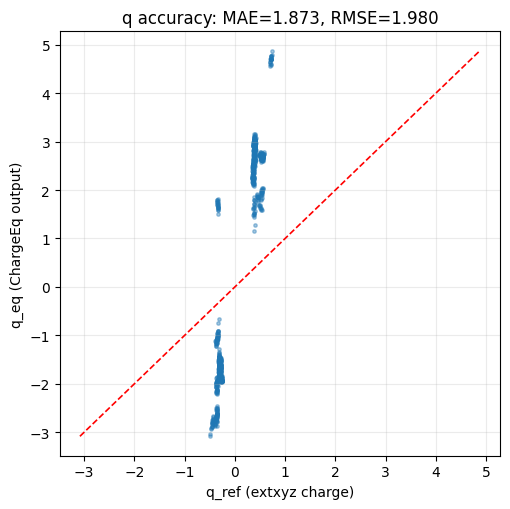

In [7]:
# ======= 电荷 q_eq 准确度（可选） =======
# 参考 q 是 extxyz 的 charge 列；q_eq 是 ChargeEq 输出。

# 拼接时处理 None
valid_pairs = [(qr, qe) for qr, qe in zip(q_ref_list, q_eq_list) if qr is not None and qe is not None]
print("q pairs collected:", len(valid_pairs))

if len(valid_pairs) > 0:
    q_ref_all = np.concatenate([p[0] for p in valid_pairs], axis=0)
    q_eq_all = np.concatenate([p[1] for p in valid_pairs], axis=0)

    mae_q = float(np.mean(np.abs(q_ref_all - q_eq_all)))
    rmse_q = float(np.sqrt(np.mean((q_ref_all - q_eq_all) ** 2)))
    print("\n=== Charge metrics ===")
    print("q MAE:", mae_q)
    print("q RMSE:", rmse_q)

    plt.figure(figsize=(5.2, 5.2))
    plt.scatter(q_ref_all, q_eq_all, s=6, alpha=0.4)
    mn = float(min(q_ref_all.min(), q_eq_all.min()))
    mx = float(max(q_ref_all.max(), q_eq_all.max()))
    plt.plot([mn, mx], [mn, mx], 'r--', lw=1.2)
    plt.xlabel('q_ref (extxyz charge)')
    plt.ylabel('q_eq (ChargeEq output)')
    plt.title(f'q accuracy: MAE={mae_q:.3f}, RMSE={rmse_q:.3f}')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("q_ref or q_eq missing in batch outputs; skip charge plot")

## 预期解释（你跑完看输出后就能验证）

- 如果 `Corrected` 版本的能量 RMSE(e/atom) **显著下降**，通常说明：
  - 误差主要来自 `ChargeEq.normalization_factor` 引起的 **长程能量尺度不一致**。
  - 经验修正乘子就是 `norm_factor^2`，即把 `SOG_potential` 除以约 `90.0474`。

- 如果修正后仍然很差，则说明问题更多可能来自：
  - ChargeEq 使用的核构造（`use_sog_kernel` / BSA 初始化）与当前实现不一致；
  - 或参考能量/单位定义与模型输出定义仍不完全对齐。


## 结果解读（对应你刚跑出来的输出）

- `ChargeEq.normalization_factor = 0.1053815`，所以 `norm_factor^2 = 0.0111053`。
- **能量对比非常正常**：
  - `Raw (pred=CACE_energy)`：`MAE(e/atom)=1.26e-4`，`RMSE(e/atom)=1.50e-4`，几乎跟 reference 一致。
  - `Corrected (SR + SOG*norm_factor^2)`：`MAE(e/atom)=0.962`，`RMSE(e/atom)=0.963`，直接把能量尺度搞坏。
- 例如第 0 个结构：
  - `ref=0.155170`，`pred=0.158192`（很好）
  - 但 `corrected=-16.841726`（相差约 17 eV/atom 量级），而且这主要来自把 `SOG_potential` 再乘了一个很小的 `norm_factor^2` 后导致长程项失真。

**核心结论**：在这个 notebook 的评估流程里，`CACE_energy` 基本上已经是“正确尺度下”的 `SR_energy + SOG_potential`；因此你现在看到的“加 Qeq 后能量差距巨大”更可能来自 **另一个评估脚本/Notebook 的对齐方式不一致**（比如：用错了 reference energy 的扣基态方式、energy_key 取错、或者数据加载方式与训练目标不完全一致），而不是 `normalization_factor` 这一项本身。

**关于 q 指标**：当前 `q pairs collected: 10`（只收集到 10 条有效 `(q_ref, q_eq)` 配对），所以 `q MAE/RMSE` 是基于很少样本的统计，代表性可能不足；另外即使电荷有偏差，能量仍可能通过长程项的结构性“抵消”而看起来接近 reference。



=== Branch consistency (first N) ===
mean(abs(pred_CACE - (SR+SOG))): 0.0
max(abs(pred_CACE - (SR+SOG))):  0.0

=== Coverage ===
structures in subset: 50
q_ref present in batch: 10
q_eq present in model out: 10
q pairs collected: 10

=== System charge check (only valid pairs) ===
q_ref(sum) mean/std: 4.999999856948852 6.050385256027946e-07
q_eq(sum)  mean/std: 47.44665451049805 1.089695499960762e-05
sys charge MAE: 42.446654653549196


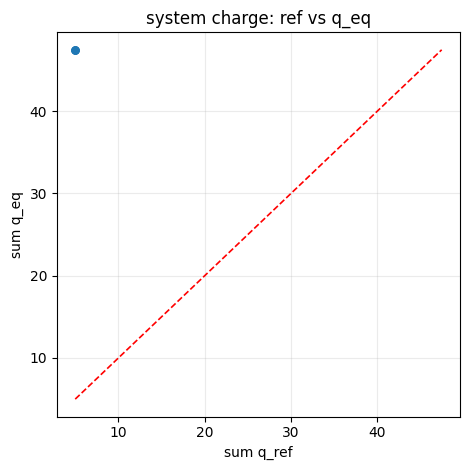

In [8]:
# 下一步诊断：确认 energy 分解关系、以及 q_ref/q_eq 覆盖率

K = min(50, len(ref_energy))

# pred_CACE 应该约等于 pred_SR + pred_SOG（否则能量拼接/取 key 有问题）
if pred_SR is not None and pred_SOG is not None:
    sum_branches = pred_SR + pred_SOG
    diff = pred_CACE - sum_branches
    print("\n=== Branch consistency (first N) ===")
    print("mean(abs(pred_CACE - (SR+SOG))):", float(np.mean(np.abs(diff))))
    print("max(abs(pred_CACE - (SR+SOG))): ", float(np.max(np.abs(diff))))
else:
    print("pred_SR / pred_SOG missing; cannot check branch consistency")

# 覆盖率（charge 是否解析进 batch；q_eq 是否在 out 中）
# q_ref_list / q_eq_list 已经在前面 cell 构建
n_q_ref = sum(1 for x in q_ref_list if x is not None)
n_q_eq = sum(1 for x in q_eq_list if x is not None)

print("\n=== Coverage ===")
print("structures in subset:", len(subset))
print("q_ref present in batch:", n_q_ref)
print("q_eq present in model out:", n_q_eq)

valid_pairs = [(qr, qe) for qr, qe in zip(q_ref_list, q_eq_list) if qr is not None and qe is not None]
print("q pairs collected:", len(valid_pairs))

# 统计一下每个结构里的 q_ref 系统电荷（sum q） vs q_eq（sum q）是否差太多
if len(valid_pairs) > 0:
    qref_sys = np.array([p[0].sum() for p in valid_pairs], dtype=np.float64)
    qeq_sys = np.array([p[1].sum() for p in valid_pairs], dtype=np.float64)
    print("\n=== System charge check (only valid pairs) ===")
    print("q_ref(sum) mean/std:", float(qref_sys.mean()), float(qref_sys.std()))
    print("q_eq(sum)  mean/std:", float(qeq_sys.mean()), float(qeq_sys.std()))
    print("sys charge MAE:", float(np.mean(np.abs(qref_sys - qeq_sys))))

    plt.figure(figsize=(4.8, 4.8))
    plt.scatter(qref_sys, qeq_sys, s=25, alpha=0.5)
    mn = float(min(qref_sys.min(), qeq_sys.min()))
    mx = float(max(qref_sys.max(), qeq_sys.max()))
    plt.plot([mn, mx], [mn, mx], 'r--', lw=1.2)
    plt.xlabel('sum q_ref')
    plt.ylabel('sum q_eq')
    plt.title('system charge: ref vs q_eq')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



=== q scaling diagnostics ===
valid_pairs: 10
norm_factor: 0.10538150852788286
q MAE/RMSE (unscaled q_eq): 1.873206615447998 1.980445146560669
q MAE/RMSE (scaled q_eq * norm_factor): 0.1529632806777954 0.17696800827980042
system charge MAE after scaling: 7.48776029890763e-07
mean(q_eq_sum / q_ref_sum): 9.489331173591534 ; expected ~ 1/norm_factor: 9.48933085101368


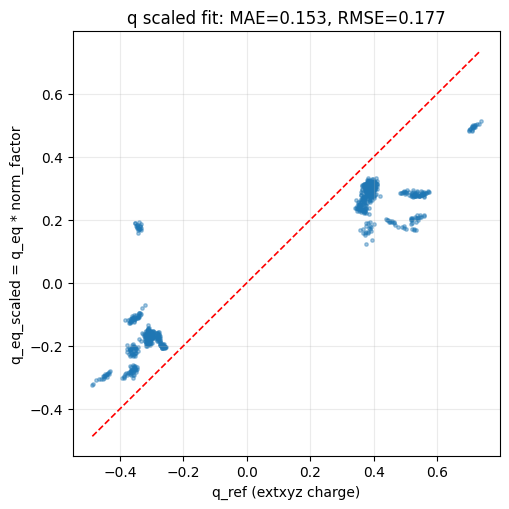

In [9]:
# 最关键修正：ChargeEq 输出的 q_eq 通常是“归一化后的电荷”
# 从你当前结果：q_eq(sum) ≈ q_ref(sum) / norm_factor
# 因此若要做 q_ref vs q_eq 的准确度对比，应使用 q_eq_scaled = q_eq * norm_factor

valid_pairs = [(qr, qe) for qr, qe in zip(q_ref_list, q_eq_list) if qr is not None and qe is not None]
print("\n=== q scaling diagnostics ===")
print("valid_pairs:", len(valid_pairs))

if len(valid_pairs) == 0:
    print("no valid q pairs; skip")
else:
    q_ref_all = np.concatenate([p[0] for p in valid_pairs], axis=0)
    q_eq_all = np.concatenate([p[1] for p in valid_pairs], axis=0)

    nf = float(norm_factor)
    q_eq_scaled = q_eq_all * nf

    mae_unscaled = float(np.mean(np.abs(q_ref_all - q_eq_all)))
    rmse_unscaled = float(np.sqrt(np.mean((q_ref_all - q_eq_all) ** 2)))

    mae_scaled = float(np.mean(np.abs(q_ref_all - q_eq_scaled)))
    rmse_scaled = float(np.sqrt(np.mean((q_ref_all - q_eq_scaled) ** 2)))

    print("norm_factor:", nf)
    print("q MAE/RMSE (unscaled q_eq):", mae_unscaled, rmse_unscaled)
    print("q MAE/RMSE (scaled q_eq * norm_factor):", mae_scaled, rmse_scaled)

    # 系统电荷（每个结构 sum q），确认比例
    qref_sys = np.array([p[0].sum() for p in valid_pairs], dtype=np.float64)
    qeq_sys = np.array([p[1].sum() for p in valid_pairs], dtype=np.float64)

    # 期待：qeq_sys * norm_factor ≈ qref_sys
    sys_mae = float(np.mean(np.abs(qref_sys - qeq_sys * nf)))
    print("system charge MAE after scaling:", sys_mae)

    ratio = float(np.mean(qeq_sys / qref_sys)) if np.all(qref_sys != 0) else None
    print("mean(q_eq_sum / q_ref_sum):", ratio, "; expected ~ 1/norm_factor:", 1.0 / nf)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(5.2, 5.2))
    plt.scatter(q_ref_all, q_eq_scaled, s=6, alpha=0.4)
    mn = float(min(q_ref_all.min(), q_eq_scaled.min()))
    mx = float(max(q_ref_all.max(), q_eq_scaled.max()))
    plt.plot([mn, mx], [mn, mx], 'r--', lw=1.2)
    plt.xlabel('q_ref (extxyz charge)')
    plt.ylabel('q_eq_scaled = q_eq * norm_factor')
    plt.title(f"q scaled fit: MAE={mae_scaled:.3f}, RMSE={rmse_scaled:.3f}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
